In [ ]:
import duckdb

# Test Query for dataset
query = """
SELECT * 
FROM 'data/raw/olist_customers_dataset.csv' 
LIMIT 5;
"""

# Run the query and show the table
result = duckdb.query(query).df()
display(result)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
# Sample question before analysis: What cities are placing the most delivered orders?

query = """
SELECT
    c.customer_city,
    c.customer_state,
    COUNT(o.order_id) AS total_orders
FROM 'data/raw/olist_orders_dataset.csv' AS o
JOIN 'data/raw/olist_customers_dataset.csv' AS c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_city, c.customer_state
ORDER By total_orders DESC
LIMIT 10;

"""
top_cities = duckdb.query(query).df()
display(top_cities)



,customer_city,customer_state,total_orders
0,sao paulo,SP,15045
1,rio de janeiro,RJ,6601
2,belo horizonte,MG,2697
3,brasilia,DF,2071
4,curitiba,PR,1489
5,campinas,SP,1406
6,porto alegre,RS,1342
7,salvador,BA,1188
8,guarulhos,SP,1144
9,sao bernardo do campo,SP,911


Matplotlib is building the font cache; this may take a moment.


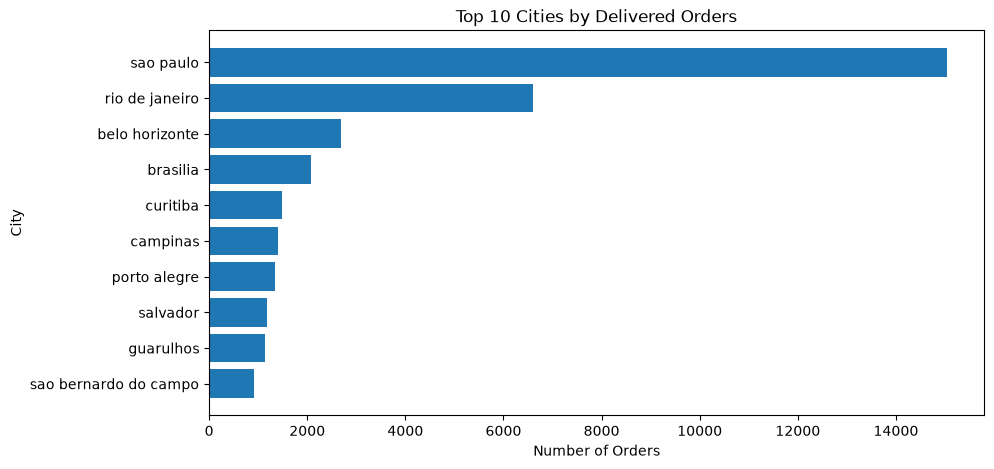

In [5]:
import matplotlib.pyplot as plt

# Create a horizontal bar chart
plt.figure(figsize=(10, 5))
plt.barh(top_cities['customer_city'], top_cities['total_orders'])
plt.gca().invert_yaxis()  # Put the #1 city at the very top
plt.title('Top 10 Cities by Delivered Orders')
plt.xlabel('Number of Orders')
plt.ylabel('City')
plt.show()

Most orders are in sao paulo and rio de janeiro, the most populus cities in brazil.
Sao paulo has double the orders of rio, this scales almost exactly to the population ( 12 mil vs 6.8 mil)
The difference in lifestyle (business in sao paulo, resortlike in rio) may explain the potential variance.

Could do a further analysis into the different item categories cities are ordering to find what items are in higher demand and where.

,avg_actual_days,avg_estimated_days,avg_delay_days
0,-12.5,-24.4,11.9


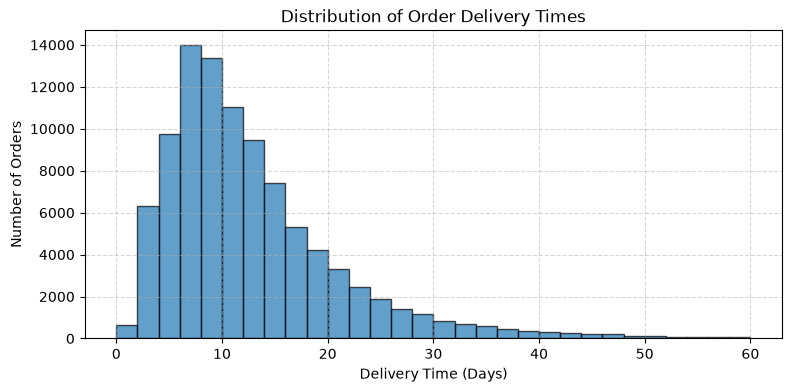

In [14]:
# Delivery exploration
# We want to find:
# average delivery days: order_delivered_customer_date - order_purchase_timestamp
# average estimated delivery days: order_estimated_delivery_date - order_purchase_timestamp
# average delay days: order_delivered_customer_date - order_estimated_delivery_date
# Negative means it arrived early, positive means it arrived late

# Data cleaning
# Filter only Delivered
query = """
SELECT
    ROUND(AVG(DATE_DIFF('day', CAST(order_delivered_customer_date AS TIMESTAMP), CAST(order_purchase_timestamp AS TIMESTAMP))),1) AS avg_actual_days,
    ROUND(AVG(DATE_DIFF('day', CAST(order_estimated_delivery_date AS TIMESTAMP), CAST(order_purchase_timestamp AS TIMESTAMP))),1) AS avg_estimated_days,
    ROUND(AVG(DATE_DIFF('day', CAST(order_delivered_customer_date AS TIMESTAMP), CAST(order_estimated_delivery_date AS TIMESTAMP))),1) AS avg_delay_days
FROM 'data/raw/olist_orders_dataset.csv'
WHERE order_status = 'delivered'
    AND order_delivered_customer_date IS NOT NULL;
"""

delivery_summary = duckdb.query(query).df()
display(delivery_summary)

# Pull the raw actual delivery days for a distribution plot
dist_query = """
SELECT 
    DATE_DIFF('day', CAST(order_purchase_timestamp AS TIMESTAMP), CAST(order_delivered_customer_date AS TIMESTAMP)) AS actual_days
FROM 'data/raw/olist_orders_dataset.csv'
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND actual_days >= 0 AND actual_days <= 60;  -- Cut off extreme outliers for cleaner plotting
"""

df_days = duckdb.query(dist_query).df()

plt.figure(figsize=(9, 4))
plt.hist(df_days['actual_days'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Order Delivery Times')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Number of Orders')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
